In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
import numpy as np


In [4]:
df0 = pd.read_csv('../data/geo_data_0.csv')
df1 = pd.read_csv('../data/geo_data_1.csv')
df2 = pd.read_csv('../data/geo_data_2.csv')

In [5]:
def preview(df):
    print(df.head())
    print()
    print(df.info())
    print()
    print("Histograma das variáveis")

    for cols in df.columns[1:5]:
        print(cols)
        df[cols].hist()
        plt.show()

    print('Média e mediana de produto: ', df['product'].mean() , " , ", df['product'].median())
    

      id        f0        f1        f2     product
0  txEyH  0.705745 -0.497823  1.221170  105.280062
1  2acmU  1.334711 -0.340164  4.365080   73.037750
2  409Wp  1.022732  0.151990  1.419926   85.265647
3  iJLyR -0.032172  0.139033  2.978566  168.620776
4  Xdl7t  1.988431  0.155413  4.751769  154.036647

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None

Histograma das variáveis
f0


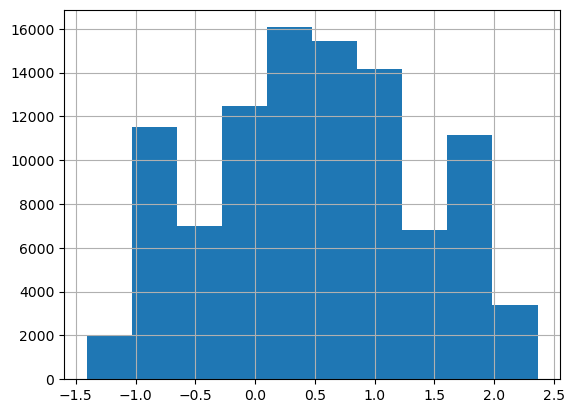

f1


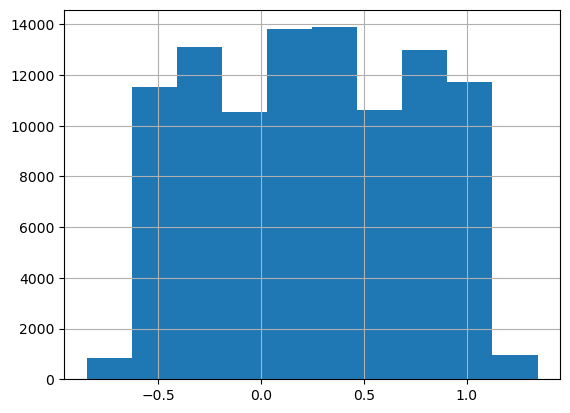

f2


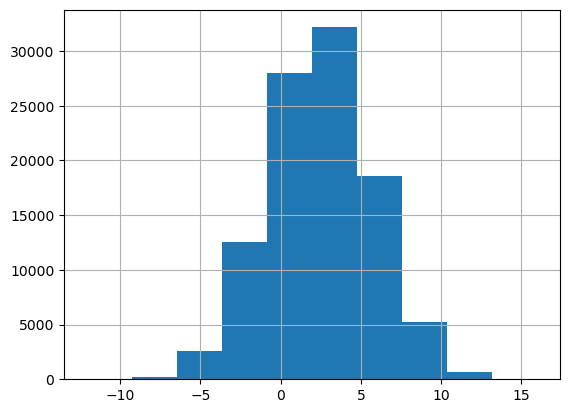

product


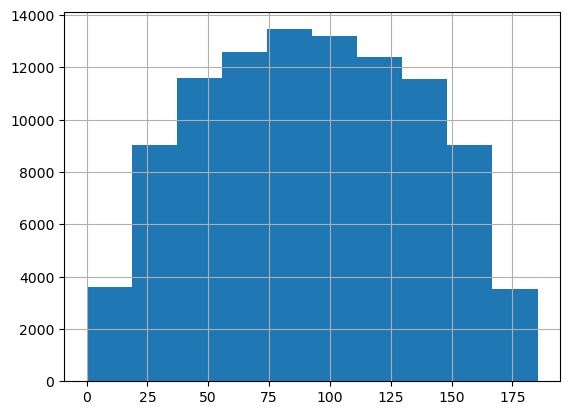

Média e mediana de produto:  92.5  ,  91.84997204396296


In [6]:
preview(df0)

In [7]:
def first_clean(df):
    before = df.shape[0]
    df_clean = df.drop_duplicates()
    after = df_clean.shape[0]
    df_clean = df_clean.drop(columns = ['id'])
    print('Foram removidas', before - after , ' linhas duplicadas, e a coluna id' )
    return df_clean
    


In [8]:
df0_clean = first_clean(df0)

Foram removidas 0  linhas duplicadas, e a coluna id


- Dataset sem nulos ou duplicatas.
- Distribuição do produto relativamente ampla, o modelo terá um range grande para previsão, cuidado com RMSE.
- variáveis com distribuições consistentes, no momento não vamos escalar, apesar da distribuição com maior range em f2, vamos utilizar o modelo aparenemtene simples e sintético desta forma.
- Retirada a coluna id que não possui qualidade preditiva, é apenas um identificador.


In [9]:
print(df0_clean.head())

         f0        f1        f2     product
0  0.705745 -0.497823  1.221170  105.280062
1  1.334711 -0.340164  4.365080   73.037750
2  1.022732  0.151990  1.419926   85.265647
3 -0.032172  0.139033  2.978566  168.620776
4  1.988431  0.155413  4.751769  154.036647


In [10]:
def split_df(df):
    X = df.drop(columns = ['product'])
    Y = df['product']
    X_train, X_valid, Y_train, Y_valid = train_test_split(X, Y, test_size = 0.25, random_state = 12345)

    print("Dados divididos em treino e validação na proporção de 0.75")
    print()
    print("Forma da planilha de treino: ", X_train.shape)
    print("Linhas de alvo do treino: ", Y_train.shape[0])
    print("Forma da planilha de validação: ", X_valid.shape)
    print("Linhas de alvo do validação: ", Y_valid.shape[0])

    return X_train, X_valid, Y_train, Y_valid

In [11]:
X_train_0, X_valid_0, Y_train_0, Y_valid_0 = split_df(df0_clean)

Dados divididos em treino e validação na proporção de 0.75

Forma da planilha de treino:  (75000, 3)
Linhas de alvo do treino:  75000
Forma da planilha de validação:  (25000, 3)
Linhas de alvo do validação:  25000


In [12]:

def model_test(xtrain, xvalid, ytrain, yvalid):
    model = LinearRegression()
    model.fit(xtrain, ytrain)
    predictions = model.predict(xvalid)
    RMSE = mean_squared_error(yvalid, predictions)**0.5

    baseline_mean = np.repeat(ytrain.mean(), len(yvalid))
    base_rmse = mean_squared_error(yvalid, baseline_mean)**0.5

    print('RMSE do modelo', RMSE)
    print('RMSE dos dados', base_rmse)
    print("Desvio do RMSE", RMSE - base_rmse)
    print()
    media_prevista = predictions.mean()
    media_target = yvalid.mean()
    print('Media do modelo', media_prevista)
    print('Media dos dados', media_target)
    print("Desvio da média", media_prevista - media_target)

    return {"model": model, "pred": predictions, "y_valid": yvalid, "rmse": RMSE, "baseline_rmse": base_rmse}

In [13]:

model_0 = model_test(X_train_0, X_valid_0, Y_train_0, Y_valid_0)


RMSE do modelo 37.5794217150813
RMSE dos dados 44.289591053907365
Desvio do RMSE -6.710169338826063

Media do modelo 92.59256778438038
Media dos dados 92.07859674082925
Desvio da média 0.5139710435511233


- nosso modelo está se mostrando consistente, com as médias proximas e um ganho de 6.7 em relação ao RMSE
- portanto temos uma redução do RMSE em ~15% se tivessemos a previsão com a utilização apenas do valor médio, ou seja, o modelo está se tornando vantajoso.
- vamos agora fazer os mesmos passos para df1 e df2

      id         f0         f1        f2     product
0  kBEdx -15.001348  -8.276000 -0.005876    3.179103
1  62mP7  14.272088  -3.475083  0.999183   26.953261
2  vyE1P   6.263187  -5.948386  5.001160  134.766305
3  KcrkZ -13.081196 -11.506057  4.999415  137.945408
4  AHL4O  12.702195  -8.147433  5.004363  134.766305

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None

Histograma das variáveis
f0


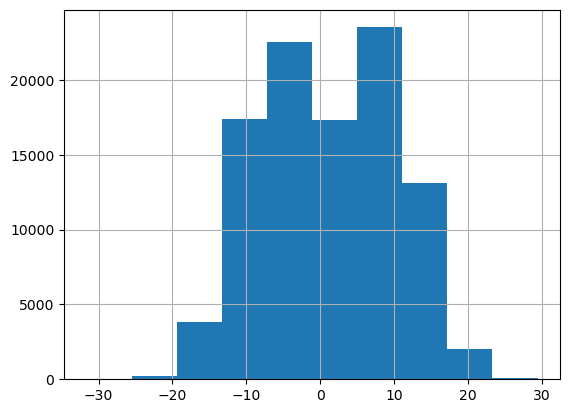

f1


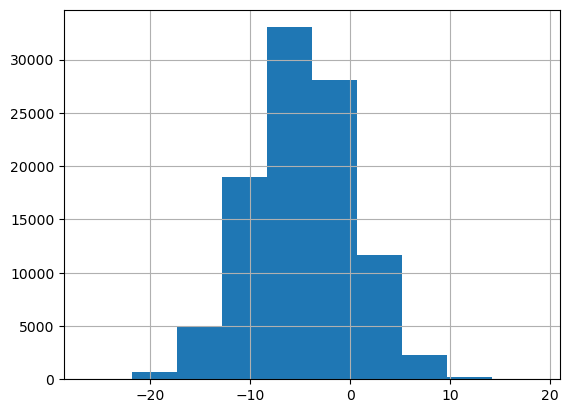

f2


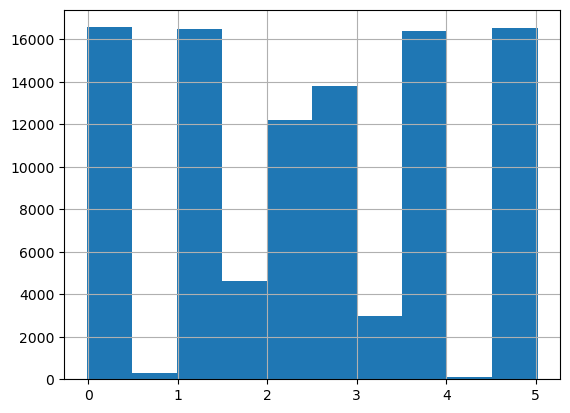

product


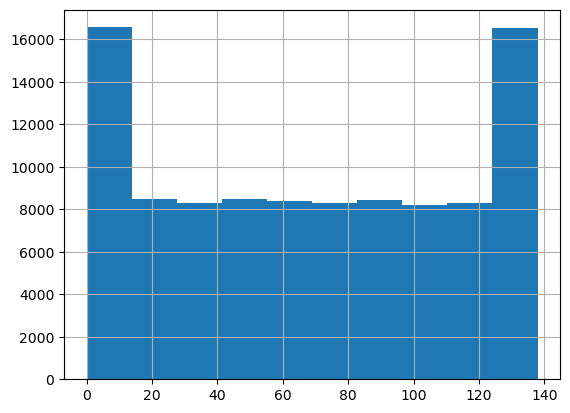

Média e mediana de produto:  68.825  ,  57.08562464628662


In [14]:
preview(df1)

In [15]:
df1_clean = first_clean(df1)
X_train_1, X_valid_1, Y_train_1, Y_valid_1 = split_df(df1_clean)
model_1 = model_test(X_train_1, X_valid_1, Y_train_1, Y_valid_1)

Foram removidas 0  linhas duplicadas, e a coluna id
Dados divididos em treino e validação na proporção de 0.75

Forma da planilha de treino:  (75000, 3)
Linhas de alvo do treino:  75000
Forma da planilha de validação:  (25000, 3)
Linhas de alvo do validação:  25000
RMSE do modelo 0.8930992867756168
RMSE dos dados 46.02144533725462
Desvio do RMSE -45.128346050479

Media do modelo 68.72854689544602
Media dos dados 68.72313602435999
Desvio da média 0.005410871086027669


      id        f0        f1        f2     product
0  fwXo0 -1.146987  0.963328 -0.828965   27.758673
1  WJtFt  0.262778  0.269839 -2.530187   56.069697
2  ovLUW  0.194587  0.289035 -5.586433   62.871910
3  q6cA6  2.236060 -0.553760  0.930038  114.572842
4  WPMUX -0.515993  1.716266  5.899011  149.600746

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None

Histograma das variáveis
f0


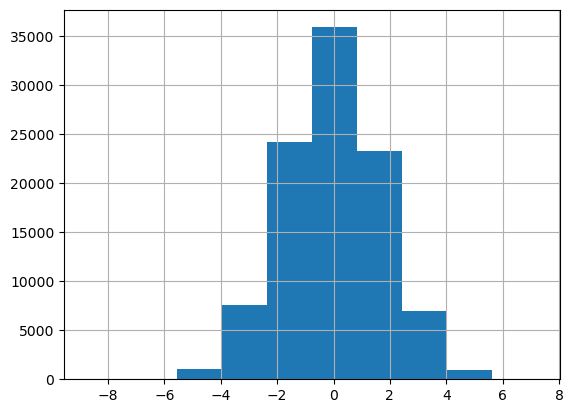

f1


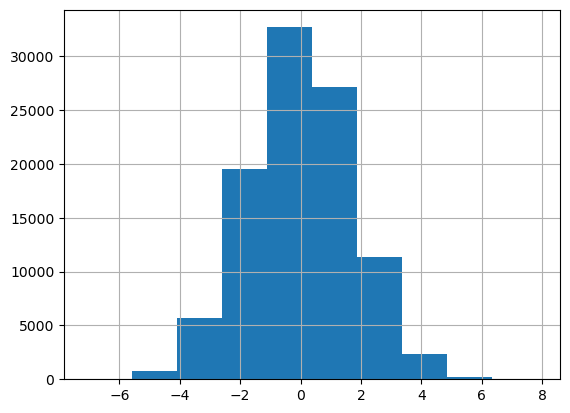

f2


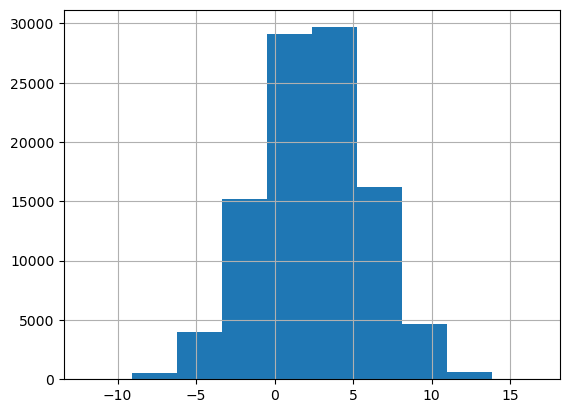

product


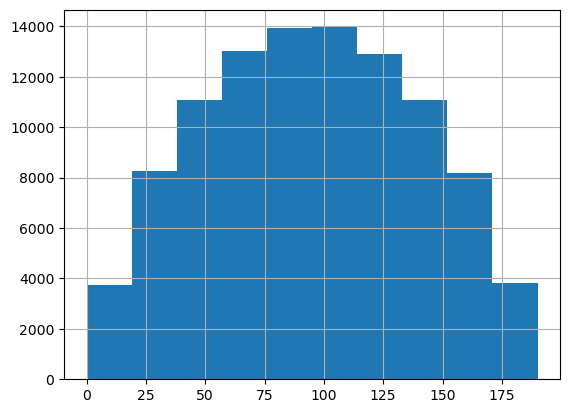

Média e mediana de produto:  95.0  ,  94.92561258990247


In [16]:
preview(df2)

In [17]:
df2_clean = first_clean(df2)
X_train_2, X_valid_2, Y_train_2, Y_valid_2 = split_df(df2_clean)
model_2 = model_test(X_train_2, X_valid_2, Y_train_2, Y_valid_2)

Foram removidas 0  linhas duplicadas, e a coluna id
Dados divididos em treino e validação na proporção de 0.75

Forma da planilha de treino:  (75000, 3)
Linhas de alvo do treino:  75000
Forma da planilha de validação:  (25000, 3)
Linhas de alvo do validação:  25000
RMSE do modelo 40.02970873393434
RMSE dos dados 44.90234968510566
Desvio do RMSE -4.87264095117132

Media do modelo 94.96504596800492
Media dos dados 94.88423280885435
Desvio da média 0.08081315915056564


In [18]:
print(f"""
Variavel           | modelo 0 | modelo 1 | modelo 2
Média real:        |{model_0['pred'].mean():.4f}   | {model_1['pred'].mean():.4f}  | {model_2['pred'].mean():.4f}
Média prevista:    |{model_0['y_valid'].mean():.4f}   | {model_1['y_valid'].mean():.4f}  | {model_2['y_valid'].mean():.4f}
RMSE:              |{model_0['rmse']:.4f}   | {model_1['rmse']:.4f}   | {model_2['rmse']:.4f}
Baseline RMSE:     |{model_0['baseline_rmse']:.4f}   | {model_1['baseline_rmse']:.4f}  | {model_2['baseline_rmse']:.4f}
""")


Variavel           | modelo 0 | modelo 1 | modelo 2
Média real:        |92.5926   | 68.7285  | 94.9650
Média prevista:    |92.0786   | 68.7231  | 94.8842
RMSE:              |37.5794   | 0.8931   | 40.0297
Baseline RMSE:     |44.2896   | 46.0214  | 44.9023



- dados de df1 e df2 tratados da mesma forma, sem dados nulos nos conjuntos e nenhum outro tratamento especial necessário para a aplicação no modelo.

In [22]:
print(df1[['f0', 'f1', 'f2', 'product']].corr())

               f0        f1        f2   product
f0       1.000000  0.182287 -0.001777 -0.030491
f1       0.182287  1.000000 -0.002595 -0.010155
f2      -0.001777 -0.002595  1.000000  0.999397
product -0.030491 -0.010155  0.999397  1.000000


- o modelo 1 possui correlação linear muito forte, gerando um RMSE menor que 1. (correlação f2 - product 0.999397)
- entretanto, a média e mediana de 'product', é inferior aos outros modelos testados, então temos uma boa precisão nas respostas, sabemos onde devemos perfurar, mas são perfurações com menor ganho, em média.

# Avaliação de provável lucro
- todas as regiões possuem valor médido de produto menor que o mínimo para obtenção de lucro (111.1) .
- o modelo 0 e 2 possuem médias maiores enquanto o modelo 1, que tem uma predição boa, possui média bem abaixo.
- a seleção dos 200 melhores poços pode ser o diferencial.

In [ ]:
#dados do breefing:
budget = 100000000
wells = 200
mean_production = 500000
min_product = 111.1
revenue_per_unit = mean_production/min_product


In [ ]:
def pot_profit(predictions, y_val):
    results = pd.DataFrame({"prediction": predictions, "target": y_val})

    top_200 = results.sort_values(by="prediction", ascending=False).head(200)
    total_volume = top_200["target"].sum()
    profit = total_volume * revenue_per_unit - budget

    return total_volume, profit


In [ ]:
vol0, prof0 = pot_profit(model_0['pred'], model_0['y_valid'])
print("Volume total da região 0 (best 200): ", vol0)
print(f"Lucro provável para best 200: R$ {prof0:.2f}")
print(f"Média da região 0: {model_0['y_valid'].mean():.4f}")


In [ ]:
vol1, prof1 = pot_profit(model_1['pred'], model_1['y_valid'])
print("Volume total da região 1 (best 200): ", vol1)
print(f"Lucro provável para best 200: R$ {prof1:.2f}")
print(f"Média da região 1: {model_1['y_valid'].mean():.4f}")


In [ ]:
vol2, prof2 = pot_profit(model_2['pred'], model_2['y_valid'])
print("Volume total da região 2 (best 200): ", vol2)
print(f"Lucro provável para best 200: R$ {prof2:.2f}")
print(f"Média da região 2: {model_2['y_valid'].mean():.4f}")



In [ ]:
print(f"""
Regiao             | modelo 0   | modelo 1   | modelo 2
Média regiao:      |{model_0['pred'].mean():.4f}     | {model_1['pred'].mean():.4f}    | {model_2['pred'].mean():.4f}
Lucro proável:     |{prof0:.2f} |{prof1:.2f} |{prof2:.2f}
Volume total:      |{vol0:.2f}    | {vol1:.2f}   | {vol2:.2f}
Média 200 best:    |{vol0/200:.2f}      | {vol1/200:.2f}     | {vol2/200:.2f}
""")

- sem uma investigação mais a fundo, apenas com os "melhores 200", a região 0 é a que mais tem potencial de lucro!

In [ ]:
def bootstraping (pred, target, n_amostras = 1000, CI = 5):

    results = pd.DataFrame({
        "predictions": pred,
        "target": target})

    profits = []
    state = np.random.RandomState(12345)
    
    for i in range(n_amostras):
        sample = results.sample(n=500, replace = True, random_state = state)
        top_200 = sample.sort_values("predictions", ascending=False).head(200)
        total_volume = top_200["target"].sum()
        profit = total_volume * revenue_per_unit - budget
        profits.append(profit)

    mean_profit = np.mean(profits)
    conf_interv = np.percentile(profits, [CI/2, 100-(CI/2)])
    risk = (np.array(profits) < 0).mean()*100

    return mean_profit, conf_interv, risk
    
    


In [ ]:
mean_profit_0, CI_0, risk_0 = bootstraping (model_0['pred'], Y_valid_0)
mean_profit_1, CI_1, risk_1 = bootstraping (model_1['pred'], Y_valid_1)
mean_profit_2, CI_2, risk_2 = bootstraping (model_2['pred'], Y_valid_2)

In [ ]:
print(f"""
Regiao             modelo 0    modelo 1   modelo 2
Média Lucro:      |{mean_profit_0/1e6:.2f}M      | {mean_profit_1/1e6:.2f}M    | {mean_profit_2/1e6:.2f}M
CI Inferior :     |{CI_0[0]/1e6:.2f}M     | {CI_1[0]/1e6:.2f}M    | {CI_2[0]/1e6:.2f}M
CI Superior:      |{CI_0[1]/1e6:.2f}M      | {CI_1[1]/1e6:.2f}M    | {CI_2[1]/1e6:.2f}M
Risco (%):        |{risk_0:.1f}        | {risk_1:.1f}      | {risk_2:.1f}
""")


- Aqui temos um resultado que explícita claramente a utilização do método bootstrap.
- Antes da aplicação, a região 1, apesar de boa previsibilidade tinha resultado médio menor que o mínimo esperado, entretanto, ao se estudar estatísticamente as probabilidades com os 200 melhores, temos a maior média de lucro, com o menor risco associado!
- Desta forma, a região sugerida para o desenvolvimento de novos poços, atendendendo aos dados do breefing é a região 1!

# CONCLUSÃO
- no modelo determinístico o lucro é superestimado, pois tem acesso a todos os poços de capacidade elevada (ou pontos extraordinários)
- no modelo de bootstrap temos uma modelagem mais próxima a operação real, com a avaliação de 500 poços por vez. O lucro médio esperado é reduzido mas os riscos são quantificados.
- Apontamos portanto a região 1 (risco < 2.5% e maior lucro médio entre as elegíveis)
